# Machine Learning Work

In [1]:
import re

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder

In [2]:
RANDOM_SEED = 42
TEST_RATIO = 0.2
DATA_BASE_PATH = Path("./data")
TARGET = "price"

In [3]:
rent_path = DATA_BASE_PATH / "apartments_for_rent_classified_10K.csv"

In [4]:
rent = pd.read_csv(rent_path, sep=";", encoding="latin1")
rent.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


## Data Cleaning

In this part of the notebook, we will clean the data. We will remove any unnecessary columns, handle missing values, and ensure that the data is in a format suitable for further analysis.

### Drop unnecessary columns

In [5]:
"""
features_to_drop is a list of columns that are not useful for the model.
The reason for dropping each column is one of the following:
- R1: Irrelevant: the column is not relevant to the model.
- R2: Redundant: the column is redundant with another column.
- R3: Need more features: the column needs more features to be useful.
- R4: Biased: the column is biased on the source.
- R6: Not useful: the column is not useful to predict the price of the property rent itself.
- R7: Unique value: the column has only one unique value.
- R8: Too many unique values: the column has too many unique values to be useful.
"""
features_to_drop = [
    "id",  # R1: Irrelevant
    "time",  # R1: Irrelevant
    "source",  # R4: Biased
    "latitude",  # R3: Need more features to relate the location to the price
    "longitude",  # R3: Need more features to relate the location to the price
    "price_display",  # R2: Redundant with the price column
    "has_photo",  # R6: Not useful
    "fee",  # R7: Unique value
    "currency",  # R7: Unique value
    "address",  # R3: Need more features to relate the location to the price
    "cityname", # R8: Low cardinality
]

rent.drop(columns=features_to_drop, inplace=True)
rent

,category,title,body,amenities,bathrooms,bedrooms,pets_allowed,price,price_type,square_feet,state
0,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,NaN,790,Monthly,101,DC
1,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,NaN,425,Monthly,106,IN
2,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,NaN,1390,Monthly,107,VA
3,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,NaN,925,Monthly,116,WA
4,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,NaN,880,Monthly,125,VA
...,...,...,...,...,...,...,...,...,...,...,...
9995,housing/rent/apartment,Five BR 5407 Abbott Place - Abbott,This unit is located at 5407 Abbott Place - Ab...,NaN,4.0,5.0,NaN,6000,Monthly,6300,MN
9996,housing/rent/apartment,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8.0,6.0,NaN,25000,Monthly,8716,CA
9997,housing/rent/apartment,Six BR 9908 Bentcross Drive,"This unit is located at 9908 Bentcross Drive, ...",NaN,8.5,6.0,NaN,11000,Monthly,11318,MD
9998,housing/rent/apartment,One BR in New York NY 10069,"Monthly Rent$4,605 -to $4,790AmenitiesThe Aldy...","Basketball,Cable or Satellite,Doorman,Hot Tub,...",NaN,1.0,NaN,4790,Monthly,40000,NY


### Drop rows with missing values

In [6]:
post_processing_features = [
    TARGET,  # target variable
    "pets_allowed",  # will be one-hot encoded
    "amenities",  # will have nlp processing
]

dropna_cols = set(rent.columns) - set(post_processing_features)

rent = rent.dropna(subset=dropna_cols)
rent.shape

(9883, 11)

In [7]:
def filter_column(df:pd.DataFrame, column:str, filter_value:str) -> pd.DataFrame:
    """
    Filter a dataframe by a column and a value.
    """
    df = df.loc[df[column] == filter_value]
    if df.empty:
        raise ValueError(f"Column {column} has no values for {filter_value}")
    return df

In [8]:
rent = filter_column(rent, "price_type", "Monthly")
rent = rent.drop(columns=["price_type"])
rent.shape

(9882, 10)

In [9]:
rent = filter_column(rent, "category", "housing/rent/apartment")
rent = rent.drop(columns=["category"])
rent.shape

(9879, 9)

### Remove outliers

In [10]:
def iqr_outlier_bounds(series: pd.Series) -> tuple[float, float]:
    """
    Calculate the IQR outlier bounds for a given series.
    The function returns a tuple with the lower and upper bounds.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound


def detect_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detect outliers in the dataframe.
    The function uses the IQR method to detect outliers.
    The function returns a dataframe with the following columns:
    - column: the name of the column
    - lower_bound: the lower bound of the IQR
    - upper_bound: the upper bound of the IQR
    - outliers_percentage: the percentage of outliers in the column
    The function only considers columns with numeric data types (float64 and int64).
    The function returns an empty dataframe if there are no outliers.
    """
    detected_outliers: list[dict] = []
    for col in df.select_dtypes(include=["float64", "int64"]).columns:
        lower_bound, upper_bound = iqr_outlier_bounds(df[col])
        outlier_mask = ~df[col].between(lower_bound, upper_bound)
        if outlier_mask.empty:
            continue
        outlier_percentage = outlier_mask.sum() / len(df[col]) * 100
        detected_outliers.append(
            {
                "column": col,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outliers_percentage": outlier_percentage,
            }
        )
    return pd.DataFrame(detected_outliers)

In [11]:
def show_boxplot(
    df: pd.DataFrame, columns: str | list[str], title: str, log_scale: bool = False
) -> None:
    """
    Show a boxplot of the given columns in the dataframe.
    The function takes the following parameters:
    - df: the dataframe to plot
    - columns: the columns to plot
    - title: the title of the plot
    - log_scale: whether to use a log scale for the x-axis
    """
    plt.figure(figsize=(8, len(columns) / 2))
    plt.title(title)
    if isinstance(columns, str):
        columns = [columns]
    data = [df[col].dropna() for col in columns]
    plt.boxplot(data, vert=False, tick_labels=columns)
    if log_scale:
        plt.xscale("log")
    plt.xlabel("Values")
    plt.ylabel("Features")
    plt.yticks(rotation=45)  # Rotate the label names
    plt.tight_layout()
    plt.show()

In [12]:
detected_outliers = detect_outliers(rent)
outliers_columns = detected_outliers["column"].tolist()

detected_outliers.sort_values(
    by="outliers_percentage", ascending=False
)

,column,lower_bound,upper_bound,outliers_percentage
3,square_feet,-25.0,1775.0,6.235449
2,price,-170.0,2814.0,6.164592
1,bedrooms,-0.5,3.5,5.162466
0,bathrooms,-0.5,3.5,0.728819


In [13]:
rent[outliers_columns].describe()

,bathrooms,bedrooms,price,square_feet
count,9879.000000,9879.000000,9879.000000,9879.000000
mean,1.380605,1.747140,1487.236866,943.357121
std,0.616095,0.941837,1078.712272,527.206860
min,1.000000,0.000000,200.000000,107.000000
25%,1.000000,1.000000,949.000000,650.000000
50%,1.000000,2.000000,1275.000000,803.000000
75%,2.000000,2.000000,1695.000000,1100.000000
max,8.500000,9.000000,52500.000000,11318.000000


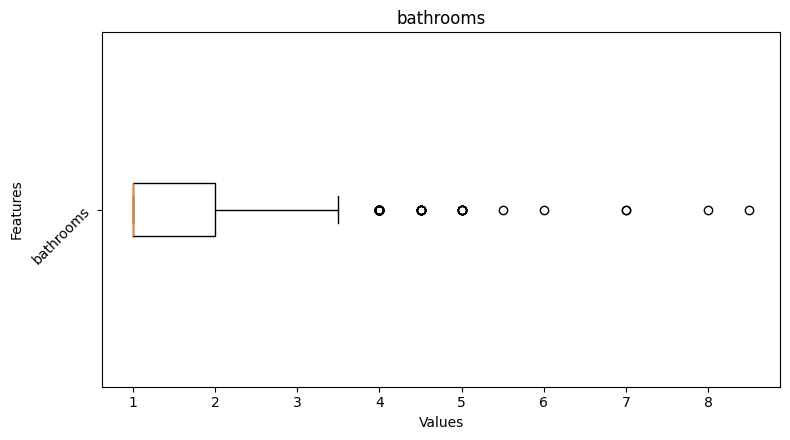

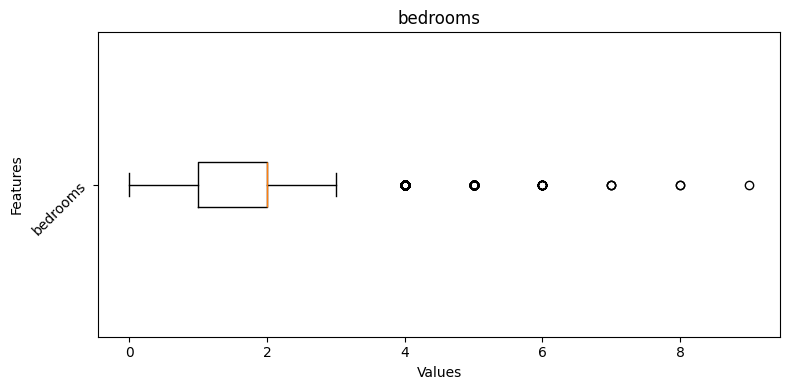

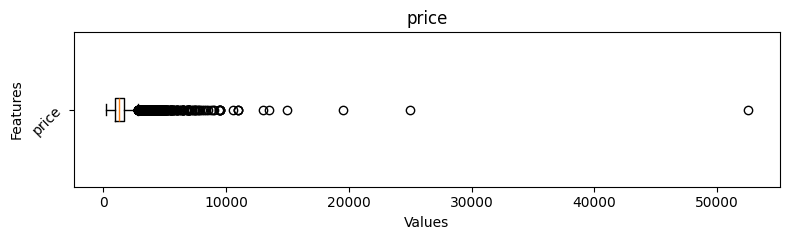

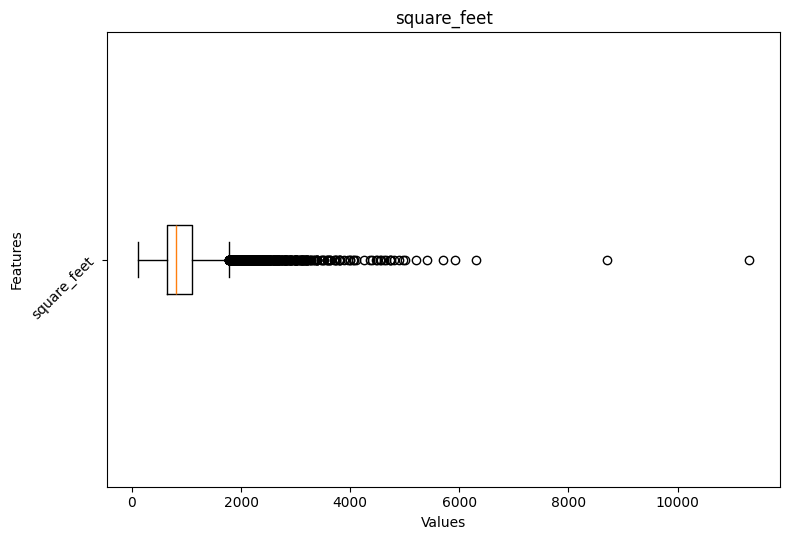

In [14]:
for col in outliers_columns:
    show_boxplot(rent, col, col)

In [15]:
def remove_outliers(df:pd.DataFrame, column:str, lower_bound:float, upper_bound:float) -> pd.DataFrame:
    """
    Remove outliers from the dataframe.
    The function uses the IQR method to detect outliers.
    """
    return df[df[column].between(lower_bound, upper_bound)]

In [16]:
rent.shape

(9879, 9)

In [17]:
for col in outliers_columns:
    lower_bound, upper_bound = iqr_outlier_bounds(rent[col])
    rent = remove_outliers(rent, col, lower_bound, upper_bound)

rent = rent.reset_index(drop=True)
rent.shape

(8490, 9)

### Convert categorical variables to numerical

In [18]:
def one_hot_encode_column(
    df: pd.DataFrame, column: str, drop_first: bool = False
) -> pd.DataFrame:
    """
    One-hot encode a given column in the dataframe.
    The function returns the dataframe with the one-hot encoded column.
    """
    encoder = OneHotEncoder(
        sparse_output=False, drop="first" if drop_first else None, handle_unknown="ignore"
    )
    encoded_column = encoder.fit_transform(df[[column]])
    encoded_df = pd.DataFrame(
        encoded_column, columns=encoder.get_feature_names_out([column])
    )
    df = df.join(encoded_df)
    df = df.drop(columns=column)
    return df

In [19]:
rent["pets_allowed"] = rent["pets_allowed"].fillna("Unknown")

rent = one_hot_encode_column(rent, column="pets_allowed", drop_first=False)

rent.head()


,title,body,amenities,bathrooms,bedrooms,price,square_feet,state,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_Unknown
0,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,1390,107,VA,0.0,0.0,0.0,1.0
1,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,925,116,WA,0.0,0.0,0.0,1.0
2,0 BR in New York NY 10019,**RARE GEM WITH PRIVATE OUTDOOR TERRACE****AVA...,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,2475,130,NY,0.0,0.0,0.0,1.0
3,Studio apartment 333 Hyde St,"This unit is located at 333 Hyde St, San Franc...",Refrigerator,1.0,0.0,1495,138,CA,0.0,0.0,0.0,1.0
4,Studio apartment 57 Taylor Street,"This unit is located at 57 Taylor Street, San ...",Refrigerator,1.0,0.0,1695,190,CA,0.0,0.0,0.0,1.0


In [20]:
rent = one_hot_encode_column(rent, column="state", drop_first=False)
rent.head()

,title,body,amenities,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,...,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,1390,107,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,925,116,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0 BR in New York NY 10019,**RARE GEM WITH PRIVATE OUTDOOR TERRACE****AVA...,"Dishwasher,Elevator,Patio/Deck,Pool,Storage",1.0,0.0,2475,130,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Studio apartment 333 Hyde St,"This unit is located at 333 Hyde St, San Franc...",Refrigerator,1.0,0.0,1495,138,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Studio apartment 57 Taylor Street,"This unit is located at 57 Taylor Street, San ...",Refrigerator,1.0,0.0,1695,190,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
items = [
    "appliances",
    "beds",
    "bedrooms",
    "pool",
    "furnished",
    "on-site laundry",
    "a/c",
    "refrigerator",
    "dishwasher",
    "parking",
    "storage",
    "washer dryer",
    "gas kitchens that",
    "a stove",
    "bathroom vanities",
    "air conditioner",
    "cable or satellite",
    "gym",
    "internet access",
    "patio/deck",
    "microwave",
    "mini fridge",
    "linens",
    "towels",
    "an indoor pool/spa",
    "fitness",
    "game",
    "theater room",
    "a catch and release pond",
    "alarm",
    "balcony",
    "ceiling fan(s)",
    "paid utilities",
    "broadband internet available",
    "disability access",
    "spa or pool",
    "pool(s)",
    "fitness center",
    "basketball court(s)",
    "smaller dogs allowed",
    "large dogs",
    "cats allowed",
    "sheltered parking",
    "heat included",
    "controlled access",
    "internet included",
    "handicapped access",
    "fitness facilities",
    "small breed dogs accepted",
    "highspeed internet available",
    "heat",
    "clubhouse",
    "elevator",
    "cable or satellite",
    "freezer",
    "living room",
    "range/oven",
    "bath",
    "bath-tub",
    "laundry",
    "public transportation",
    "hard wood floors",
    "dishwasher",
    "elevator",
    "patio/deck",
    "pool",
    "storage",
    "in-unit laundry",
    "wood floors",
    "stainless steel appliances",
    "new appliances",
    "big closets",
    "laundry rooms",
    "washer and dryers",
    "on-site garage",
    "full-service health club",
    "25 meter salt water pool",
    "vr spin cycling room",
    "sauna",
    "steam room",
    "bus line",
    "refrigerator",
    "cable or satellite",
    "clubhouse",
    "parking",
    "ac",
    "basketball",
    "cable or satellite",
    "gym",
    "internet access",
]


def extract_quantity(text, item):
    pattern = rf"(\d+)\s*{re.escape(item)}|{re.escape(item)}\s*(\d+)"
    match = re.search(pattern, text, re.IGNORECASE)
    if match:
        num = match.group(1) or match.group(2)
        return int(num)
    return 0


for item in items:
    col_name = item.lower().replace(" ", "_").replace("/", "_")
    rent[col_name] = rent["body"].fillna("").apply(lambda x: extract_quantity(x, item))


rent[
    [
        col_name
        for item in items
        for col_name in [item.lower().replace(" ", "_").replace("/", "_")]
    ]
].head()

,appliances,beds,bedrooms,pool,furnished,on-site_laundry,a_c,refrigerator,dishwasher,parking,...,bus_line,refrigerator,cable_or_satellite,clubhouse,parking,ac,basketball,cable_or_satellite,gym,internet_access
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
unique_items = list(set(items))

item_cols = [item.lower().replace(" ", "_").replace("/", "_") for item in unique_items]

valid_cols = [
    col
    for col in item_cols
    if col in rent.columns and pd.api.types.is_numeric_dtype(rent[col])
]

cols_to_check = valid_cols + ["price"]

correlations = (
    rent[cols_to_check].corr(numeric_only=True)["price"].sort_values(ascending=False)
)


rent.corr(numeric_only=True)['price'].sort_values(ascending=False).head(10)

price          1.000000
state_CA       0.377740
square_feet    0.309543
bathrooms      0.270593
state_NJ       0.195777
state_WA       0.175498
state_MA       0.173980
state_MD       0.118096
state_DC       0.111347
state_NY       0.041308
Name: price, dtype: float64

In [23]:
amenities_list = [
    "AC",
    "Alarm",
    "Basketball",
    "Cable or Satellite",
    "Cable Ready",
    "Ceiling Fan(s)",
    "Clubhouse",
    "Dishwasher",
    "Elevator",
    "Fireplace",
    "Garbage Disposal",
    "Gated",
    "Gym",
    "Hot Tub",
    "Internet Access",
    "Microwave",
    "Paid Utilities",
    "Parking",
    "Patio/Deck",
    "Playground",
    "Pool",
    "Refrigerator",
    "Storage",
    "TV",
    "Tennis",
    "View",
    "Washer Dryer",
    "Wood Floors",
]

amenities_cols = [
    item.lower().replace(" ", "_").replace("/", "_") for item in amenities_list
]

for amenity, col_name in zip(amenities_list, amenities_cols):
    pattern = re.compile(re.escape(amenity), re.IGNORECASE)
    rent[col_name] = (
        rent["body"].fillna("").apply(lambda x: 1 if pattern.search(x) else 0)
    )

print(rent[amenities_cols].head())
rent = rent.drop(columns=["amenities"])
rent.head()

   ac  alarm  basketball  cable_or_satellite  cable_ready  ceiling_fan(s)  \
0   0      0           0                   0            0               0   
1   0      0           0                   0            0               0   
2   1      0           0                   0            0               0   
3   0      0           0                   0            0               0   
4   0      0           0                   0            0               0   

   clubhouse  dishwasher  elevator  fireplace  ...  patio_deck  playground  \
0          0           0         0          0  ...           0           0   
1          0           0         0          0  ...           0           0   
2          0           0         0          0  ...           0           0   
3          0           0         0          0  ...           0           0   
4          0           0         0          0  ...           0           0   

   pool  refrigerator  storage  tv  tennis  view  washer_dryer  wood

,title,body,bathrooms,bedrooms,price,square_feet,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_Unknown,...,basketball,cable_ready,fireplace,garbage_disposal,gated,hot_tub,playground,tv,tennis,view
0,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",1.0,0,1390,107,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",1.0,0,925,116,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
2,0 BR in New York NY 10019,**RARE GEM WITH PRIVATE OUTDOOR TERRACE****AVA...,1.0,0,2475,130,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,Studio apartment 333 Hyde St,"This unit is located at 333 Hyde St, San Franc...",1.0,0,1495,138,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,Studio apartment 57 Taylor Street,"This unit is located at 57 Taylor Street, San ...",1.0,0,1695,190,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
